# Benchmarking against MASIF ligand

MASIF ligand is set up as a multi-class classification problem.

* Which protein chain is the pocket? We can use all chains specified by the MASIF PDB chain ID's and just pair them with the ligand.
* PDB chain IDs with multiple distinct ligands. But the coordinates are distinct, so they should just be treated as separate examples.
* PDB chain IDs with multiple same ligands. We can deduplicate and just pick one example? 
* TODO: check on the class imbalance across the ligands.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import biotite.structure as bs
import biotite.structure.io.pdb as pdb
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob

from atomica.data.converter import ligand_utils
from atomica.data import filter_for_segment

MASIF_LIGAND_LABELS = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

MASIF_DATA_DIR = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/baselines/masif/data/masif_ligand/lists/"
MASIF_LIGAND_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00c-ligand_coords/"
PDB_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00b-pdbs_assembly/"
ATOMICA_DATA_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/"

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Protein-Ligand structures to process

In [14]:
def get_chains_for_ligand(pdb_id: str, lig_code: str) -> list[str]:
    """
    Get the chains for a given ligand code.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    ligand = structure[:, structure.res_name == lig_code]
    ligand = list(zip(ligand.chain_id, ligand.res_id))
    return list(set(ligand))


def get_chains(pdb_id: str) -> list[str]:
    """
    Get the chains for a given PDB ID.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    structure = structure[:, bs.filter_canonical_amino_acids(structure)]
    chains = list(set(structure.chain_id))
    return chains

In [ ]:
to_process = []

with open(os.path.join(MASIF_DATA_DIR, "sequence_split_list.txt"), "r") as f:
    lines = f.readlines()
pdb_chain_ids = [line.strip() for line in lines]

for pdb_chain_id in tqdm(pdb_chain_ids, desc="Processing PDB chain IDs", total=len(pdb_chain_ids)):
    pdb_id = pdb_chain_id.split("_")[0]
    ligand_type = MASIF_LIGAND_DIR + f"{pdb_id}_ligand_types.npy"
    ligands = np.load(ligand_type)
    ligands = ligands.astype(str)
    for ligand in np.unique(ligands):
        lig_chains = get_chains_for_ligand(pdb_id, ligand)
        rec_chains = pdb_chain_id.split("_")[1]
        valid_chains = get_chains(pdb_id)
        rec_chains = [chain for chain in rec_chains if chain in valid_chains]
        for lig_chain, lig_resi in lig_chains:
            to_process.append({
                "pdb_id": pdb_id,
                "pdb_path": PDB_DIR + f"{pdb_id}.pdb",
                "chain1": "_".join(rec_chains),
                "chain2": lig_chain,
                "lig_code": ligand,
                "lig_resi": lig_resi,
            })

to_process_df = pd.DataFrame(to_process)
to_process_df['label'] = to_process_df['lig_code'].map(lambda x: MASIF_LIGAND_LABELS.index(x))
to_process_df['lig_smiles'] = to_process_df['lig_code'].apply(lambda x: ligand_utils.get_ligand_smiles(x))


Processing PDB chain IDs: 100%|██████████| 1468/1468 [03:02<00:00,  8.03it/s]


In [16]:
to_process_df['lig_code'].value_counts()

lig_code
ADP    757
HEM    473
FAD    446
COA    339
NAD    306
SAM    260
NAP    218
Name: count, dtype: int64

In [17]:
to_process_df.to_csv("masif_ligand_pdbs_to_process.csv", index=False)

Run `process_masif_ligand_pdbs.sh` to process the PDBs.

## Remove the ligand residues from the processed graphs

In [82]:
for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A.parquet")
    df = df.drop_duplicates(subset=['id']) # if there are multiple ligands on the same chain, drop the duplicates

    # Filter for only the pocket residues
    data_cols = ['X','B','A','atom_positions','block_lengths','segment_ids'] 
    filtered_data = df.apply(
        lambda row: filter_for_segment({k: row[k] for k in data_cols}, 0), axis=1
    )
    df[data_cols] = pd.json_normalize(filtered_data).to_numpy()
    df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")

Compare pocket sizes, FAD is the largest pocket and ADP is the smallest.

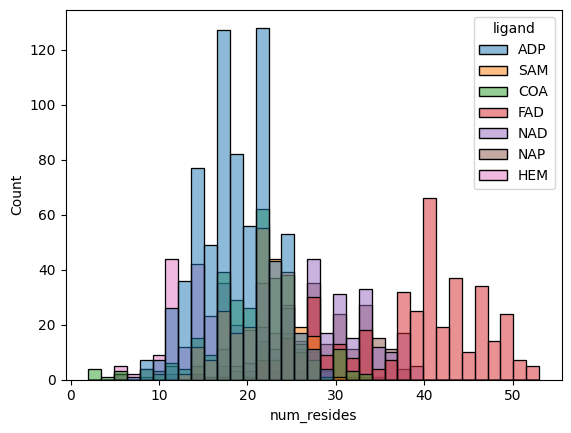

In [86]:
df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_6A_pocket_only.parquet")
pocket_size = pd.DataFrame({
    'num_resides': df['B'].apply(lambda x: len(x)), 
    'ligand': df['id'].str.split('_').str[-1]
})
pocket_size.groupby('ligand').agg(
    mean_num_resides=('num_resides', 'mean'),
    std_num_resides=('num_resides', 'std'),
)

sns.histplot(pocket_size, x='num_resides', hue='ligand')
plt.show()

## Train test splits

In [83]:
def _clean_pdb_chain_id(pdb_chain_id: str) -> str:
    pdb_id, chain_ids, *_ = pdb_chain_id.split('_')
    chain_ids = "".join(sorted(chain_ids))
    return pdb_id + "_" + chain_ids

train = np.load(os.path.join(MASIF_DATA_DIR, "train_pdbs_sequence.npy"))
train = train.astype(str)  # Convert byte strings to regular strings
train = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in train]

val = np.load(os.path.join(MASIF_DATA_DIR, "val_pdbs_sequence.npy"))
val = val.astype(str)  # Convert byte strings to regular strings
val = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in val]

test = np.load(os.path.join(MASIF_DATA_DIR, "test_pdbs_sequence.npy"))
test = test.astype(str)  # Convert byte strings to regular strings
test = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in test]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Train val overlap: {len(set(train) & set(val))}")
print(f"Test val overlap: {len(set(test) & set(val))}")

Train: 1036, Val: 115, Test: 287
Train val overlap: 0
Test val overlap: 0


In [84]:
def _assign_split(item_id: str) -> str:
    pdb_chain_id = _clean_pdb_chain_id(item_id)
    if pdb_chain_id in train:
        return 'train'
    elif pdb_chain_id in val:
        return 'val'
    elif pdb_chain_id in test:
        return 'test'

for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")
    df['split'] = df['id'].apply(_assign_split)
    df.loc[df['id'] == '1FFT_ACB_A_HEM', 'split'] = 'train' # 1FFT_ABCD is in the train set of MASIF

    assert not df['split'].isna().any()

    # # Keep only the first ligand per PDB
    # # A lot of PDBs are symmetric, so we keep only the first ligand per PDB.
    # # Unclear how MASIF handle this, but this makes the dataset more comparable in size.
    # df['id_fixed'] = df['id'].apply(lambda x: "_".join(x.split('_')[:2] + x.split('_')[-1:]))
    # df = df.drop_duplicates('id_fixed')
    # df.drop(columns=['id_fixed'], inplace=True)

    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split].copy()
        split_df.drop(columns=['split'], inplace=True)
        print(f"{split} {dist_th}A: {len(split_df)}, ligands: {split_df['id'].str.split('_').str[-1].value_counts().to_dict()}")
        split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")

train 4A: 1808, ligands: {'ADP': 526, 'FAD': 302, 'COA': 237, 'NAD': 206, 'HEM': 205, 'SAM': 187, 'NAP': 145}
val 4A: 199, ligands: {'ADP': 45, 'HEM': 29, 'NAD': 28, 'NAP': 27, 'COA': 26, 'FAD': 25, 'SAM': 19}
test 4A: 459, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 56, 'SAM': 50, 'NAD': 49, 'COA': 47, 'NAP': 28}
train 5A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 5A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 5A: 466, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'NAD': 49, 'COA': 48, 'NAP': 28}
train 6A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 6A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 6A: 467, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'COA': 49, 'NAD': 49, 'NAP': 28}
train 7A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'H

Unsure if training individually or merging is better for the different distance thresholds. So trying both.

In [5]:
for split in ['train', 'val', 'test']:
    split_dfs = []
    for dist_th in range(8,13):
        split_df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")
        split_dfs.append(split_df)
    split_df = pd.concat(split_dfs)
    split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_8-12A_pocket_only_{split}.parquet")

## ATOMICA Ligand Predictions

In [3]:
from atomica.models import MultiClassClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset
from torch.utils.data import DataLoader
from atomica.trainers import Trainer
import torch

model_checkpoints={
    # 4: "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_23/checkpoint/epoch164_step2970.pt",
    5: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_24/checkpoint/epoch92_step2976.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_25/checkpoint/epoch104_step3360.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_33/checkpoint/epoch127_step4096.pt",
    ],
    6: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_21/checkpoint/epoch147_step6808.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_27/checkpoint/epoch106_step4922.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_34/checkpoint/epoch98_step4554.pt",
    ],
    7: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_22/checkpoint/epoch55_step3528.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_28/checkpoint/epoch197_step12474.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_35/checkpoint/epoch183_step11592.pt",
    ],
    8: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_15/checkpoint/epoch59_step5100.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_29/checkpoint/epoch146_step12495.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_36/checkpoint/epoch68_step5865.pt",
    ],
    9: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_16/checkpoint/epoch47_step5280.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_26/checkpoint/epoch197_step21780.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_37/checkpoint/epoch199_step22200.pt",
    ],
    10: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_19/checkpoint/epoch48_step6664.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_31/checkpoint/epoch187_step25568.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_39/checkpoint/epoch193_step26384.pt",
    ],
    11: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_20/checkpoint/epoch34_step5740.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_30/checkpoint/epoch187_step30644.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_38/checkpoint/epoch81_step13366.pt"
    ],
    12: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_14/checkpoint/epoch64_step12545.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_32/checkpoint/epoch140_step27072.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_40/checkpoint/epoch151_step29032.pt",
    ],
}

def get_model(model_checkpoint: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    model = MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    return model

atomica_results = []
for dist_th in range(5,13):
    dataset = MultiClassLabelledPDBDataset(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/masif_ligand_pdbs_{dist_th}A_pocket_only_test.parquet")
    for i, model_checkpoint in enumerate(model_checkpoints[dist_th]):
        model = get_model(model_checkpoint)

        atomica_preds = []
        model.eval()
        model.to("cuda")
        batch_size = 16
        for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc=f"Processing {dist_th}A"):
            with torch.no_grad():
                batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
                batch = MultiClassLabelledPDBDataset.collate_fn(batch)
                batch = Trainer.to_device(batch, "cuda")
                atomica_preds.append(model.infer(batch).cpu().numpy())
        atomica_preds = np.concatenate(atomica_preds)
        atomica_labels = np.array([x['label'] for x in dataset.data])
        pred_indxes = np.argmax(atomica_preds, axis=1)
        df = pd.DataFrame({
            'dist_th': dist_th,
            'id': [x['id'] for x in dataset.data],
            'label': atomica_labels,
            'pred': pred_indxes,
            'pred_probability': [atomica_preds[i] for i in range(len(atomica_preds))],
            'seed': i,
        })
        atomica_results.append(df)
atomica_results_df = pd.concat(atomica_results)

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:118: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  torch.has_mkldnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`

In [4]:
atomica_results_df

,dist_th,id,label,pred,pred_probability,seed
0,5,4CRM_PX_P_ADP,0,0,"[0.8620518, 0.10156639, 1.1549962e-05, 0.00048...",464
1,5,3KB1_AB_B_ADP,0,0,"[0.6596711, 0.08859863, 7.78609e-05, 0.0011936...",464
2,5,3KB1_AB_A_ADP,0,4,"[0.25795323, 0.044751175, 0.0003725348, 0.0020...",464
3,5,4HLU_AD_D_ADP,0,0,"[0.8632393, 0.10130384, 1.0979356e-05, 0.00046...",464
4,5,4HLU_AD_A_ADP,0,0,"[0.85915965, 0.10131691, 1.2399164e-05, 0.0005...",464
...,...,...,...,...,...,...
462,12,4M7T_A_A_SAM,6,6,"[0.017903423, 1.9502802e-11, 5.3041543e-29, 0....",464
463,12,1JG4_A_A_SAM,6,3,"[1.2286422e-07, 3.5106063e-07, 6.483581e-26, 0...",464
464,12,4NJJ_AB_B_SAM,6,0,"[0.998808, 6.531798e-14, 2.3700697e-24, 6.4926...",464
465,12,4NJJ_AB_A_SAM,6,0,"[0.9974873, 1.6224693e-12, 7.2646703e-22, 3.66...",464


In [9]:
atomica_grouped_results_df = atomica_results_df[atomica_results_df['dist_th'].isin(range(5,13))].groupby('id').agg(
    label=('label', 'first'),
    pred=('pred', list),
    pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
    pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
    pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
    dist_th=('dist_th', list),
).reset_index()

atomica_grouped_results_df['pred_mode_accuracy'] = atomica_grouped_results_df['pred_mode'] == atomica_grouped_results_df['label']
atomica_grouped_results_df['pred_mode_probability_accuracy'] = atomica_grouped_results_df['pred_mode_probability'] == atomica_grouped_results_df['label']

In [7]:
# no ensemble accuracy
for dist_th in range(5,13):
    df = atomica_results_df[atomica_results_df['dist_th'] == dist_th].groupby('id').agg(
        label=('label', 'first'),
        pred=('pred', list),
        pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
        pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
        pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
        dist_th=('dist_th', list),
    ).reset_index()
    accuracy = np.sum(df['pred_mode'] == df['label']) / len(df)
    accuracy_probability = np.sum(df['pred_mode_probability'] == df['label']) / len(df)
    print(f"ATOMICA Accuracy {dist_th}A: {accuracy:.4f}, {accuracy_probability:.4f}")

ATOMICA Accuracy 5A: 0.7554, 0.7639
ATOMICA Accuracy 6A: 0.7580, 0.7859
ATOMICA Accuracy 7A: 0.7516, 0.7816
ATOMICA Accuracy 8A: 0.7516, 0.8009
ATOMICA Accuracy 9A: 0.7238, 0.7580
ATOMICA Accuracy 10A: 0.7602, 0.7816
ATOMICA Accuracy 11A: 0.7259, 0.7473
ATOMICA Accuracy 12A: 0.6424, 0.6959


5-13 with 3 seeds each, accuracy is now 0.8480 when you average the probabilities.

In [10]:
accuracy = atomica_grouped_results_df['pred_mode_accuracy'].mean()
print(f"ATOMICA ensemble vote accuracy: {accuracy:.4f}")

accuracy = atomica_grouped_results_df['pred_mode_probability_accuracy'].mean()
print(f"ATOMICA ensemble probability accuracy: {accuracy:.4f}")

ATOMICA ensemble vote accuracy: 0.8308
ATOMICA ensemble probability accuracy: 0.8480


## MASIF predictions

In [11]:
MASIF_PREDICTIONS_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/test_set_predictions"

In [12]:
masif_results = []
for pred_fname in glob(f"{MASIF_PREDICTIONS_DIR}/*_logits.npy"):
    item_id = os.path.basename(pred_fname).replace("_logits.npy", "")
    labels = np.load(os.path.join(MASIF_PREDICTIONS_DIR, f"{item_id}_labels.npy"))
    preds = np.load(pred_fname)
    if preds.shape == (0, ):
        print(f"No predictions for {item_id}")
        continue
    elif preds.shape[1:] != (100, 1, 1, 7):
        print(f"Invalid shape for {item_id}: {preds.shape}")
        continue
    preds = preds.mean(axis=1).squeeze()
    if preds.ndim == 1:
        preds = preds[None, :]
    for label, pred in zip(labels, preds):
        masif_results.append({
            'receptor_id': item_id,
            'label': label,
            'ligand': MASIF_LIGAND_LABELS[label],
            'pred': pred.argmax(axis=0),
            'pred_probability': pred,
        })
masif_results_df = pd.DataFrame(masif_results)
masif_results_df['pred_accuracy'] = masif_results_df['label'] == masif_results_df['pred']

No predictions for 3D36_ACB
No predictions for 2REQ_AB
No predictions for 1X7P_AB
No predictions for 2OWM_AC
No predictions for 3UQD_ACBD
No predictions for 1XX6_AB
No predictions for 4ZNL_A
No predictions for 4H6Q_A
No predictions for 5HMN_CE
No predictions for 4BLV_A
No predictions for 5L8J_AB


In [13]:
accuracy = masif_results_df['pred_accuracy'].mean()
print(f"MASIF Accuracy: {accuracy:.4f}")

MASIF Accuracy: 0.7871


### Merge the two results, since they don't have the exact same IDs
Also group the results by unique receptor and ligand pairs, as some receptors have multiple identical ligands.

In [14]:
atomica_grouped_results_df['receptor_id'] = atomica_grouped_results_df['id'].str.split('_').str[:2].str.join('_')
atomica_grouped_results_df['ligand'] = atomica_grouped_results_df['id'].str.split('_').str[-1]
atomica_grouped_results_df['masif_id'] = atomica_grouped_results_df['receptor_id'] + '_' + atomica_grouped_results_df['ligand']
masif_results_df['masif_id'] = masif_results_df['receptor_id'] + '_' + masif_results_df['ligand']

In [15]:
match_masif = atomica_grouped_results_df['masif_id'].isin(masif_results_df['masif_id'])
atomica_grouped_results_match_masif_df = atomica_grouped_results_df[match_masif].groupby('masif_id').agg(
    pred_mode_accuracy=('pred_mode_accuracy', 'mean'),
    pred_mode_probability_accuracy=('pred_mode_probability_accuracy', 'mean'),
)
atomica_grouped_results_match_masif_df.mean()

pred_mode_accuracy                0.850198
pred_mode_probability_accuracy    0.863095
dtype: float64

In [16]:
masif_results_df.groupby('masif_id').agg(
    accuracy=('pred_accuracy', 'mean'),
).mean()

accuracy    0.80754
dtype: float64

## Conclusion
MASIF and ATOMICA perform comparably. For further improvements of ATOMICA:
* ensembling different patch sizes was very useful, let's see how far we can push this.
* MASIF and ATOMICA are using different signals, so it might be useful to include some of the phsicochemical features from MASIF in the ATOMICA model.

Other baselines
* ESM 2 and ESM 3 embeddings of the pocket residues?
* Fold seek embeddings?

In [17]:
## Per-class AUROC and AUPRC calculation

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd

def calculate_per_class_metrics(y_true, y_pred_proba, class_names=None):
    """
    Calculate per-class AUROC and AUPRC for multiclass classification.
    
    Args:
        y_true: True labels (integers from 0 to num_classes-1)
        y_pred_proba: Predicted probabilities of shape (n_samples, n_classes)
        class_names: Optional list of class names for better output
    
    Returns:
        dict: Dictionary containing per-class metrics
    """
    n_classes = y_pred_proba.shape[1]
    
    if class_names is None:
        class_names = [f'Class_{i}' for i in range(n_classes)]
    
    # Binarize the true labels for one-vs-rest calculation
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Calculate per-class metrics
    results = {}
    
    for i in range(n_classes):
        class_name = class_names[i]
        
        # Check if class exists in the data
        if y_true_bin[:, i].sum() == 0:
            print(f"Warning: No samples found for {class_name}, skipping...")
            continue
        
        # AUROC (one-vs-rest)
        try:
            auroc = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
            results[f'{class_name}_AUROC'] = auroc
        except ValueError as e:
            print(f"Warning: Could not calculate AUROC for {class_name}: {e}")
            results[f'{class_name}_AUROC'] = np.nan
        
        # AUPRC (one-vs-rest)
        try:
            auprc = average_precision_score(y_true_bin[:, i], y_pred_proba[:, i])
            results[f'{class_name}_AUPRC'] = auprc
        except ValueError as e:
            print(f"Warning: Could not calculate AUPRC for {class_name}: {e}")
            results[f'{class_name}_AUPRC'] = np.nan
    
    # Calculate macro averages (excluding NaN values)
    auroc_values = [v for k, v in results.items() if k.endswith('_AUROC') and not np.isnan(v)]
    auprc_values = [v for k, v in results.items() if k.endswith('_AUPRC') and not np.isnan(v)]
    
    results['Macro_Avg_AUROC'] = np.mean(auroc_values) if auroc_values else np.nan
    results['Macro_Avg_AUPRC'] = np.mean(auprc_values) if auprc_values else np.nan
    
    return results

# Calculate metrics for ATOMICA predictions
print("ATOMICA Model Metrics:")
atomica_metrics = calculate_per_class_metrics(atomica_grouped_results_df['label'], np.stack(atomica_grouped_results_df['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in atomica_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n" + "="*50 + "\n")

# Calculate metrics for MASIF predictions  
print("MASIF Model Metrics:")
masif_metrics = calculate_per_class_metrics(masif_results_df['label'], np.stack(masif_results_df['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in masif_metrics.items():
    print(f"{metric}: {value:.4f}")


ATOMICA Model Metrics:
ADP_AUROC: 0.9691
ADP_AUPRC: 0.9586
COA_AUROC: 0.9704
COA_AUPRC: 0.8560
FAD_AUROC: 0.9896
FAD_AUPRC: 0.9676
HEM_AUROC: 0.9977
HEM_AUPRC: 0.9877
NAD_AUROC: 0.9306
NAD_AUPRC: 0.7787
NAP_AUROC: 0.9557
NAP_AUPRC: 0.7565
SAM_AUROC: 0.9779
SAM_AUPRC: 0.7925
Macro_Avg_AUROC: 0.9701
Macro_Avg_AUPRC: 0.8711


MASIF Model Metrics:
ADP_AUROC: 0.9282
ADP_AUPRC: 0.9307
COA_AUROC: 0.9356
COA_AUPRC: 0.6745
FAD_AUROC: 0.9403
FAD_AUPRC: 0.7777
HEM_AUROC: 0.9859
HEM_AUPRC: 0.8974
NAD_AUROC: 0.9143
NAD_AUPRC: 0.5870
NAP_AUROC: 0.9518
NAP_AUPRC: 0.6683
SAM_AUROC: 0.9722
SAM_AUPRC: 0.8578
Macro_Avg_AUROC: 0.9469
Macro_Avg_AUPRC: 0.7705


Per-class AUROC and AUPRC Comparison:
             Metric  ATOMICA   MASIF
0         ADP_AUROC   0.9691  0.9282
1         ADP_AUPRC   0.9586  0.9307
2         COA_AUROC   0.9704  0.9356
3         COA_AUPRC   0.8560  0.6745
4         FAD_AUROC   0.9896  0.9403
5         FAD_AUPRC   0.9676  0.7777
6         HEM_AUROC   0.9977  0.9859
7         HEM_AUPRC   0.9877  0.8974
8         NAD_AUROC   0.9306  0.9143
9         NAD_AUPRC   0.7787  0.5870
10        NAP_AUROC   0.9557  0.9518
11        NAP_AUPRC   0.7565  0.6683
12        SAM_AUROC   0.9779  0.9722
13        SAM_AUPRC   0.7925  0.8578
14  Macro_Avg_AUROC   0.9701  0.9469
15  Macro_Avg_AUPRC   0.8711  0.7705


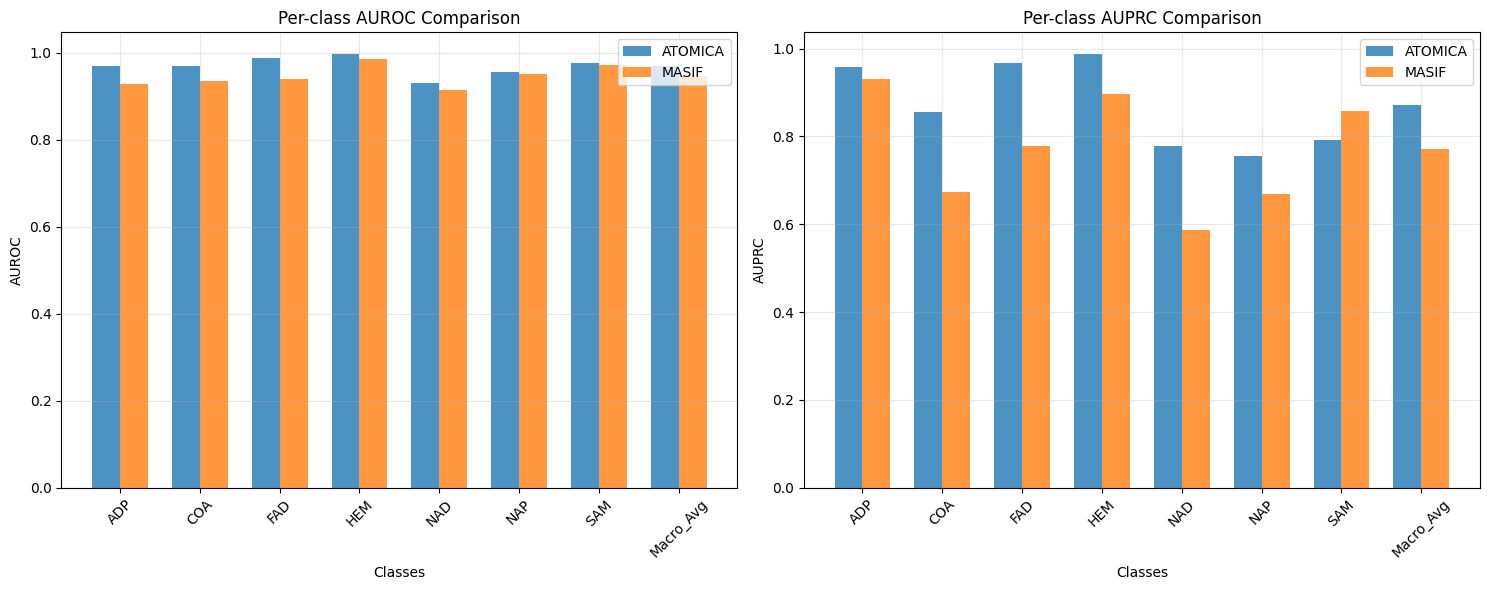

In [18]:
## Create comparison table and visualization

# Create comparison DataFrame
comparison_data = []
for metric in atomica_metrics.keys():
    if metric.startswith('ADP_') or metric.startswith('COA_') or metric.startswith('FAD_') or \
       metric.startswith('HEM_') or metric.startswith('NAD_') or metric.startswith('NAP_') or \
       metric.startswith('SAM_') or metric.startswith('Macro_Avg_'):
        comparison_data.append({
            'Metric': metric,
            'ATOMICA': atomica_metrics[metric],
            'MASIF': masif_metrics[metric]
        })

comparison_df = pd.DataFrame(comparison_data)
print("Per-class AUROC and AUPRC Comparison:")
print(comparison_df.round(4))

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# AUROC comparison
auroc_data = comparison_df[comparison_df['Metric'].str.contains('AUROC')]
if not auroc_data.empty:
    x = np.arange(len(auroc_data))
    width = 0.35
    
    ax1.bar(x - width/2, auroc_data['ATOMICA'], width, label='ATOMICA', alpha=0.8)
    ax1.bar(x + width/2, auroc_data['MASIF'], width, label='MASIF', alpha=0.8)
    
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('AUROC')
    ax1.set_title('Per-class AUROC Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels([m.replace('_AUROC', '') for m in auroc_data['Metric']], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# AUPRC comparison
auprc_data = comparison_df[comparison_df['Metric'].str.contains('AUPRC')]
if not auprc_data.empty:
    x = np.arange(len(auprc_data))
    width = 0.35
    
    ax2.bar(x - width/2, auprc_data['ATOMICA'], width, label='ATOMICA', alpha=0.8)
    ax2.bar(x + width/2, auprc_data['MASIF'], width, label='MASIF', alpha=0.8)
    
    ax2.set_xlabel('Classes')
    ax2.set_ylabel('AUPRC')
    ax2.set_title('Per-class AUPRC Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([m.replace('_AUPRC', '') for m in auprc_data['Metric']], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
## Additional Analysis and Interpretation

# Class distribution analysis
print("Class Distribution in Test Set:")
class_counts = pd.Series(labels).value_counts().sort_index()
class_proportions = class_counts / len(labels)
for i, (class_name, count, prop) in enumerate(zip(MASIF_LIGAND_LABELS, class_counts, class_proportions)):
    print(f"{class_name}: {count} samples ({prop:.3f})")

print(f"\nTotal samples: {len(labels)}")

# Performance analysis
print("\nPerformance Analysis:")
print("="*50)

# Find best and worst performing classes for each model
atomica_auroc = {k: v for k, v in atomica_metrics.items() if k.endswith('_AUROC') and not np.isnan(v)}
atomica_auprc = {k: v for k, v in atomica_metrics.items() if k.endswith('_AUPRC') and not np.isnan(v)}

masif_auroc = {k: v for k, v in masif_metrics.items() if k.endswith('_AUROC') and not np.isnan(v)}
masif_auprc = {k: v for k, v in masif_metrics.items() if k.endswith('_AUPRC') and not np.isnan(v)}

if atomica_auroc:
    best_atomica_auroc = max(atomica_auroc, key=atomica_auroc.get)
    worst_atomica_auroc = min(atomica_auroc, key=atomica_auroc.get)
    print(f"ATOMICA - Best AUROC: {best_atomica_auroc} ({atomica_auroc[best_atomica_auroc]:.4f})")
    print(f"ATOMICA - Worst AUROC: {worst_atomica_auroc} ({atomica_auroc[worst_atomica_auroc]:.4f})")

if atomica_auprc:
    best_atomica_auprc = max(atomica_auprc, key=atomica_auprc.get)
    worst_atomica_auprc = min(atomica_auprc, key=atomica_auprc.get)
    print(f"ATOMICA - Best AUPRC: {best_atomica_auprc} ({atomica_auprc[best_atomica_auprc]:.4f})")
    print(f"ATOMICA - Worst AUPRC: {worst_atomica_auprc} ({atomica_auprc[worst_atomica_auprc]:.4f})")

print()

if masif_auroc:
    best_masif_auroc = max(masif_auroc, key=masif_auroc.get)
    worst_masif_auroc = min(masif_auroc, key=masif_auroc.get)
    print(f"MASIF - Best AUROC: {best_masif_auroc} ({masif_auroc[best_masif_auroc]:.4f})")
    print(f"MASIF - Worst AUROC: {worst_masif_auroc} ({masif_auroc[worst_masif_auroc]:.4f})")

if masif_auprc:
    best_masif_auprc = max(masif_auprc, key=masif_auprc.get)
    worst_masif_auprc = min(masif_auprc, key=masif_auprc.get)
    print(f"MASIF - Best AUPRC: {best_masif_auprc} ({masif_auprc[best_masif_auprc]:.4f})")
    print(f"MASIF - Worst AUPRC: {worst_masif_auprc} ({masif_auprc[worst_masif_auprc]:.4f})")

# Model comparison summary
print("\nModel Comparison Summary:")
print("="*50)
print(f"ATOMICA Macro-Avg AUROC: {atomica_metrics.get('Macro_Avg_AUROC', 'N/A'):.4f}")
print(f"MASIF Macro-Avg AUROC: {masif_metrics.get('Macro_Avg_AUROC', 'N/A'):.4f}")
print(f"ATOMICA Macro-Avg AUPRC: {atomica_metrics.get('Macro_Avg_AUPRC', 'N/A'):.4f}")
print(f"MASIF Macro-Avg AUPRC: {masif_metrics.get('Macro_Avg_AUPRC', 'N/A'):.4f}")

# Calculate improvement
if 'Macro_Avg_AUROC' in atomica_metrics and 'Macro_Avg_AUROC' in masif_metrics:
    auroc_improvement = atomica_metrics['Macro_Avg_AUROC'] - masif_metrics['Macro_Avg_AUROC']
    print(f"\nAUROC Improvement (ATOMICA - MASIF): {auroc_improvement:+.4f}")

if 'Macro_Avg_AUPRC' in atomica_metrics and 'Macro_Avg_AUPRC' in masif_metrics:
    auprc_improvement = atomica_metrics['Macro_Avg_AUPRC'] - masif_metrics['Macro_Avg_AUPRC']
    print(f"AUPRC Improvement (ATOMICA - MASIF): {auprc_improvement:+.4f}")


Class Distribution in Test Set:
ADP: 1 samples (1.000)

Total samples: 1

Performance Analysis:
ATOMICA - Best AUROC: HEM_AUROC (0.9977)
ATOMICA - Worst AUROC: NAD_AUROC (0.9306)
ATOMICA - Best AUPRC: HEM_AUPRC (0.9877)
ATOMICA - Worst AUPRC: NAP_AUPRC (0.7565)

MASIF - Best AUROC: HEM_AUROC (0.9859)
MASIF - Worst AUROC: NAD_AUROC (0.9143)
MASIF - Best AUPRC: ADP_AUPRC (0.9307)
MASIF - Worst AUPRC: NAD_AUPRC (0.5870)

Model Comparison Summary:
ATOMICA Macro-Avg AUROC: 0.9701
MASIF Macro-Avg AUROC: 0.9469
ATOMICA Macro-Avg AUPRC: 0.8711
MASIF Macro-Avg AUPRC: 0.7705

AUROC Improvement (ATOMICA - MASIF): +0.0232
AUPRC Improvement (ATOMICA - MASIF): +0.1006
